In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest


In [26]:
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.expand_frame_repr", False)


In [27]:
df = pd.read_csv("../data/processed/final_features.csv")
df.head()


,month,total_updates,cumulative_updates,rolling_avg,trend_deviation
0,2024-11-01,17163105,1333904561,0.000000e+00,0.000000e+00
1,2024-12-01,26193030,1360097591,0.000000e+00,0.000000e+00
2,2025-01-01,24819163,1384916754,2.272510e+07,2.094064e+06
3,2025-02-01,23424931,1408341685,2.481237e+07,-1.387444e+06
4,2025-03-01,20637885,1428979570,2.296066e+07,-2.322775e+06


In [28]:
print(df.columns.tolist())



['month', 'total_updates', 'cumulative_updates', 'rolling_avg', 'trend_deviation']


In [29]:
df = pd.read_csv("../data/processed/final_features.csv")


In [30]:
print(df.columns)


Index(['month', 'total_updates', 'cumulative_updates', 'rolling_avg',
       'trend_deviation'],
      dtype='object')


In [31]:
df["update_growth_rate"] = df["total_updates"].pct_change()
df.fillna(0, inplace=True)



In [32]:
features = [
    "total_updates",
    "update_growth_rate",
    "trend_deviation"
]

X = df[features]
X.head()


,total_updates,update_growth_rate,trend_deviation
0,17163105,0.000000,0.000000e+00
1,26193030,0.526124,0.000000e+00
2,24819163,-0.052452,2.094064e+06
3,23424931,-0.056176,-1.387444e+06
4,20637885,-0.118978,-2.322775e+06


In [33]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [34]:
model = IsolationForest(
    n_estimators=200,
    contamination=0.15,
    random_state=42
)

df["anomaly_flag"] = model.fit_predict(X_scaled)


In [35]:
df["anomaly"] = df["anomaly_flag"].map({1: "Normal", -1: "Anomaly"})
df[df["anomaly"] == "Anomaly"]


,month,total_updates,cumulative_updates,rolling_avg,trend_deviation,update_growth_rate,anomaly_flag,anomaly
1,2024-12-01,26193030,1360097591,0.0,0.0,0.526124,-1,Anomaly
8,2025-07-01,23263837,1509468289,20428132.0,2835705.0,0.187730,-1,Anomaly


In [36]:
def classify_anomaly(row):
    if row["update_growth_rate"] > 0.3:
        return "Sudden Spike in Updates"
    elif row["update_growth_rate"] < -0.3:
        return "Sudden Drop in Updates"
    elif abs(row["trend_deviation"]) > 2000000:
        return "Unusual Volume Deviation"
    else:
        return "Irregular Pattern"

df["anomaly_type"] = df.apply(classify_anomaly, axis=1)


In [37]:
def recommend_action(row):
    if row["anomaly_type"] == "Sudden Spike in Updates":
        return "Increase staff, check system load"
    elif row["anomaly_type"] == "Sudden Drop in Updates":
        return "Check connectivity and system uptime"
    elif row["anomaly_type"] == "Unusual Volume Deviation":
        return "Operational audit recommended"
    else:
        return "Monitor closely"

df["recommended_action"] = df.apply(recommend_action, axis=1)


In [38]:
df[df["anomaly_flag"] == -1][
    ["month", "total_updates", "update_growth_rate",
     "anomaly_type", "recommended_action"]
]


,month,total_updates,update_growth_rate,anomaly_type,recommended_action
1,2024-12-01,26193030,0.526124,Sudden Spike in Updates,"Increase staff, check system load"
8,2025-07-01,23263837,0.187730,Unusual Volume Deviation,Operational audit recommended


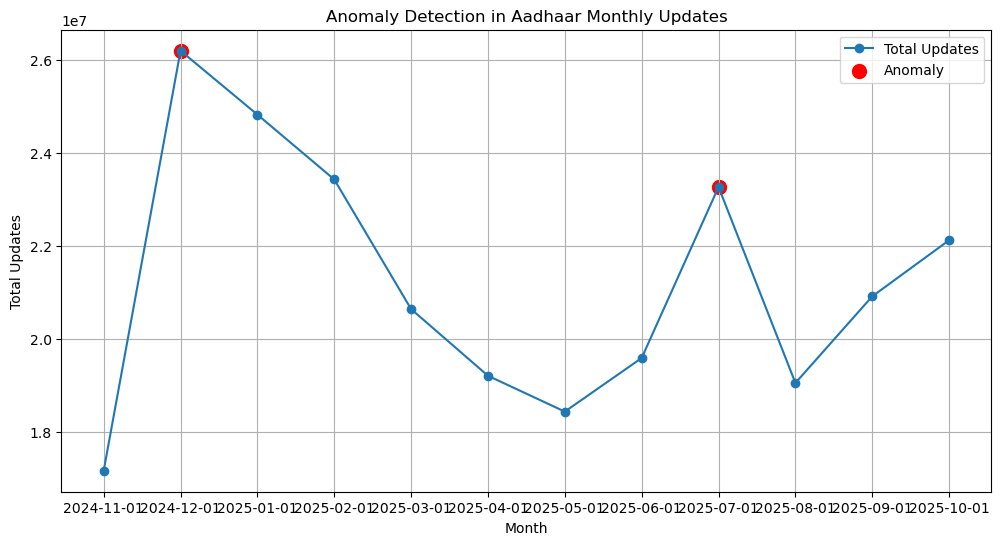

In [39]:
plt.figure(figsize=(12,6))

plt.plot(df["month"], df["total_updates"], label="Total Updates", marker="o")

anoms = df[df["anomaly_flag"] == -1]
plt.scatter(
    anoms["month"],
    anoms["total_updates"],
    color="red",
    s=100,
    label="Anomaly"
)

plt.title("Anomaly Detection in Aadhaar Monthly Updates")
plt.xlabel("Month")
plt.ylabel("Total Updates")
plt.legend()
plt.grid(True)
plt.show()


In [40]:
df.to_csv("../outputs/aadhaar_anomaly_final_report.csv", index=False)
print("Final anomaly report saved successfully!")


Final anomaly report saved successfully!
